In [13]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('insurance.csv')

In [7]:
df.shape

(1338, 7)

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [18]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [19]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

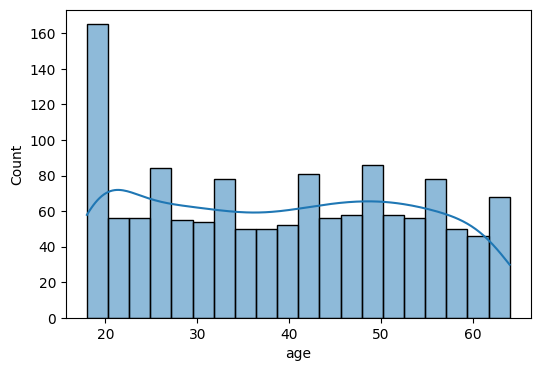

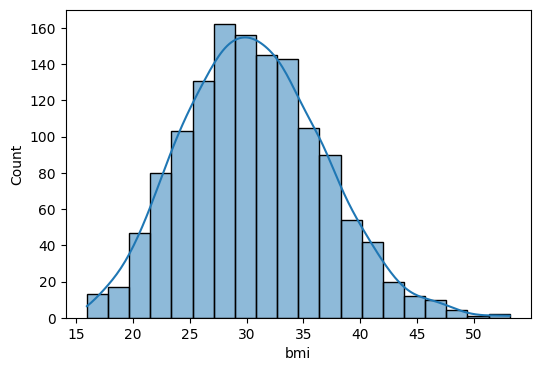

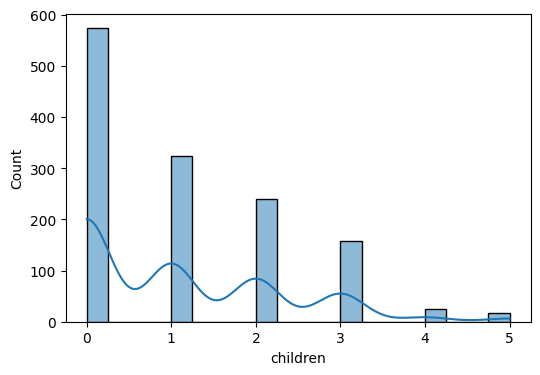

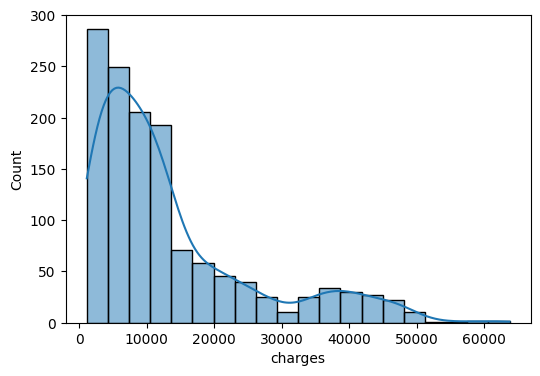

In [20]:
numeric_col =["age","bmi","children","charges"]
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True , bins=20)

<Axes: xlabel='children', ylabel='count'>

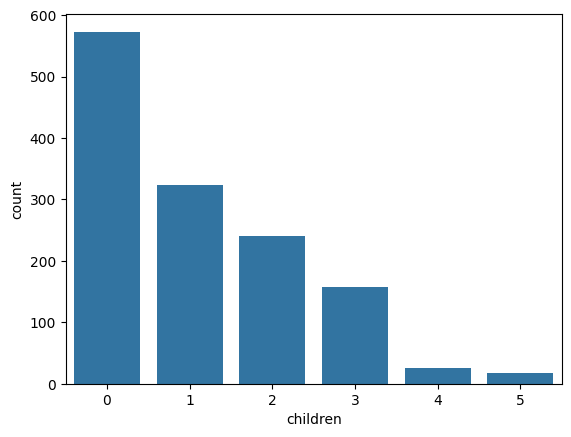

In [21]:
sns.countplot(x= df["children"])

<Axes: xlabel='sex', ylabel='count'>

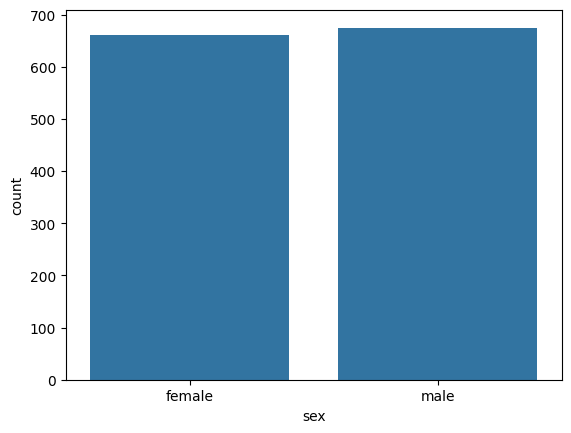

In [22]:
sns.countplot(x=df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

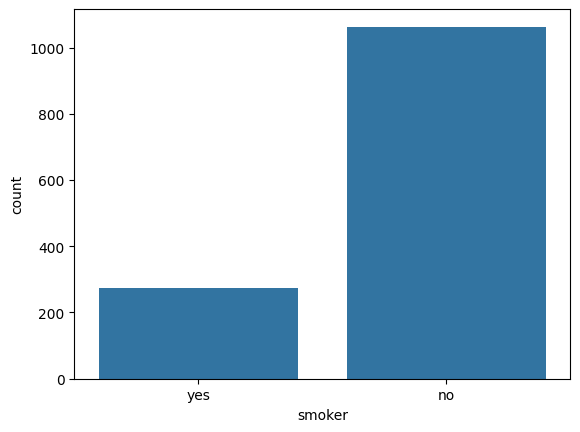

In [23]:
sns.countplot(x=df["smoker"])

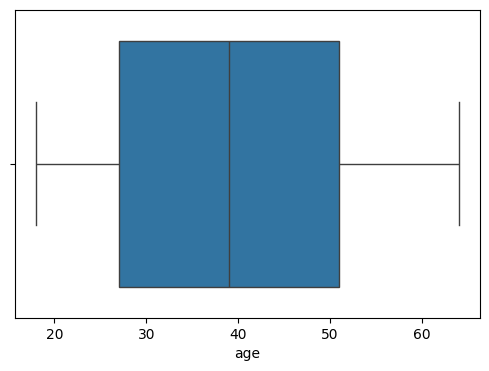

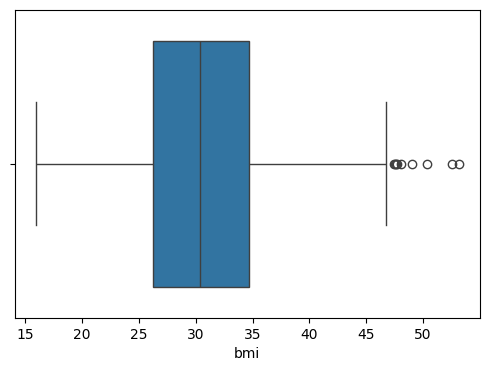

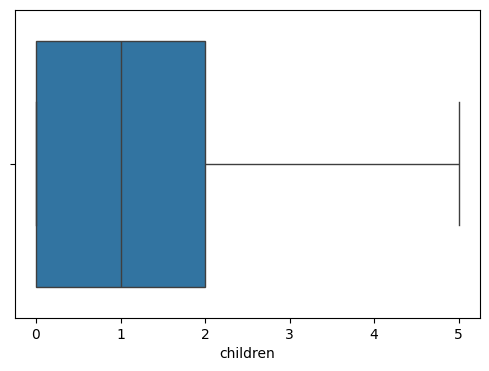

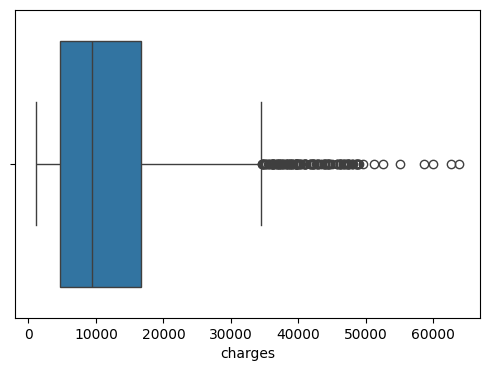

In [24]:
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

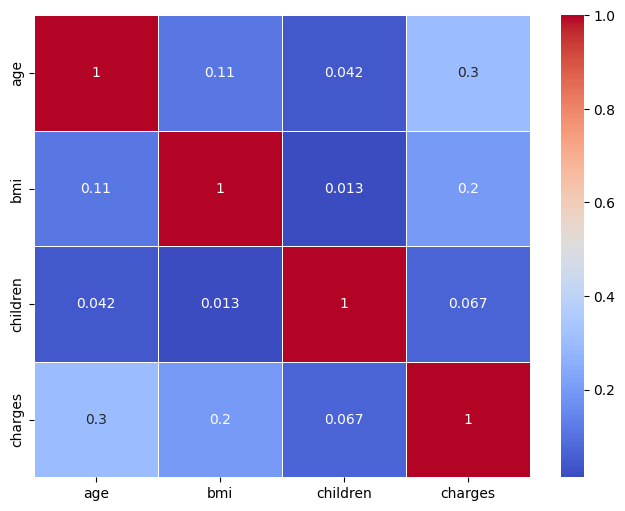

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)

In [29]:

df_cleaned=df.copy()
df_cleaned.to_csv("insurance_cleaned.csv", index=False)
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [30]:
X=df.drop("charges",axis=1)
Y=df["charges"]

In [31]:
#one hot encoding
X_encoded =pd.get_dummies(X,drop_first=True)
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    Y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ["age", "bmi", "children"]
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [35]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3472.98,1927.83, 636.5 ,...,-391.76,-838.92,-659.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8948
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [37]:
y_pred= model.predict(X_test)



In [39]:
comparison=pd.DataFrame({
    "Actual charges":y_test,
    "Predicted charges":y_pred
})
comparison.head()

,Actual charges,Predicted charges
900,8688.85885,8143.693884
1064,5708.86700,5737.115683
1256,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4177.045561036324
MSE: 35478020.6752356
RMSE: 5956.342894363587
R2 Score: 0.8069287081198012


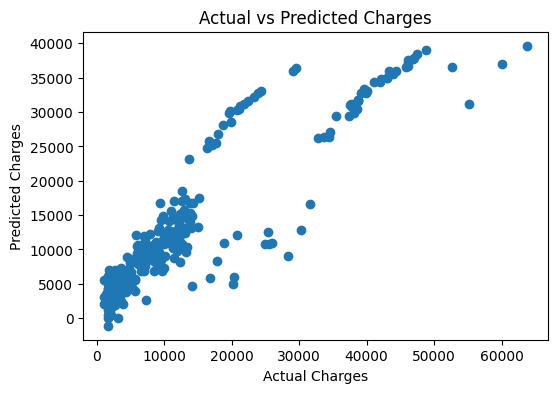

In [41]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

Random Forest MAE: 2657.61175591903
Random Forest RMSE: 4724.019756137546
Random Forest R2 Score: 0.8785544152089233


In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,age,0.135697
1,bmi,0.216251
2,children,0.022922
3,sex_male,0.007060
4,smoker_yes,0.600777
5,region_northwest,0.006676
6,region_southeast,0.006059
7,region_southwest,0.004558


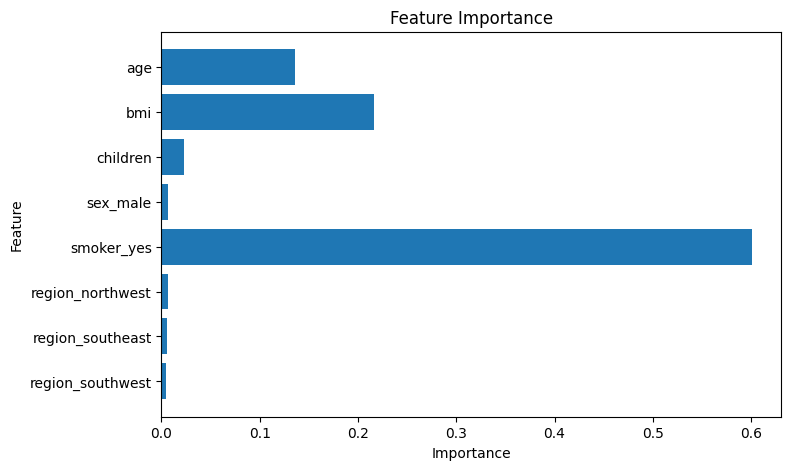

In [45]:
plt.figure(figsize=(8, 5))

plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [47]:
final_df = X_encoded.copy()
final_df["charges"] = Y

final_df.to_csv("cleaned_encoded_insurance.csv", index=False)

In [48]:
import joblib

joblib.dump(rf_model, "insurance_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']